#### konlpy 정상동작 확인

In [1]:
# 오류 발생을 방지하기 위한 코드들
import jpype
from konlpy import jvm
from konlpy.tag import Okt

# -----------------------------------------------------------------
# 1. JVM 초기화: Konlpy 사용을 위한 Java Virtual Machine 시작
# -----------------------------------------------------------------

# JVM이 이미 시작되었다면 종료 (JVM cannot be restarted 오류 방지)
if jpype.isJVMStarted():
    jpype.shutdownJVM() 

try:
    # Konlpy 내부 함수를 사용하여 JVM 시작 (가장 안정적인 방식)
    jvm.init_jvm() # JVM은 최초 1회만 실행함
    print("✅ Konlpy JVM 시작 성공.")

    # -------------------------------------------------------------
    # 2. Konlpy 작동 확인: Okt 객체 생성 및 형태소 분석 실행
    # -------------------------------------------------------------
    okt = Okt()     # Okt (Open Korean Text) 형태소 분석기 객체
    
    # 작동 테스트
    test_sentence = "새로운 파일에서 Konlpy가 정상적으로 작동하는지 확인합니다."
    result = okt.morphs(test_sentence)      # 형태소 단위로 분석
    
    print("✅ Konlpy 최종 작동 확인.")
    print(f"테스트 문장: {test_sentence}")
    print(f"분석 결과: {result}")
    
except Exception as e:
    # 오류 발생 시 JVM 종료 시도 (다음 시도를 위해)
    if jpype.isJVMStarted():
        jpype.shutdownJVM()
    print(f"🛑 Konlpy 실행 오류 발생: {e}")

finally:
    # 셀 실행 후 JVM을 종료하여 다음 셀 실행이나 커널 재시작에 대비
    # (워드클라우드 작업 중에는 이 코드를 잠시 주석 처리할 수도 있습니다.)
    # if jpype.isJVMStarted():
    #     jpype.shutdownJVM() 
    pass

✅ Konlpy JVM 시작 성공.
✅ Konlpy 최종 작동 확인.
테스트 문장: 새로운 파일에서 Konlpy가 정상적으로 작동하는지 확인합니다.
분석 결과: ['새로운', '파일', '에서', 'Konlpy', '가', '정상', '적', '으로', '작동', '하는지', '확인', '합니다', '.']


In [2]:
import pandas as pd

#### 데이터 준비

In [3]:
# ------------------------------
#   파일 경로
# ------------------------------
data_file = 'data/증권뉴스_2024-11-02.csv'

# ------------------------------
#   불러올 컬럼명
# ------------------------------
col_name = 'title'

# ------------------------------
#   데이터 불러오기
# ------------------------------
data = pd.read_csv(data_file).loc[:,col_name].dropna()  # 'title' 컬럼만 선택, 결측치(NaN)를 제거

# ------------------------------
#   내용 컬럼을 하나의 문장으로 합치기
# ------------------------------
text = ' '.join(data)   # 모든 제목을 공백으로 연결하여 하나의 문자열
text

'메타, 만져서 느끼는 ‘촉각 로봇’ 개발…휴머노이드 발전 촉진할 듯 \'어행\'을 떠나요…최대 반값에 사는 수산대축제 트럼프 vs 해리스…다음주 美대선, 누가 대통령 돼야 내 주식 오르나 中 내주 재정정책 승인 전망…WSJ “회의론 더 크다” \'회계 투명성\' 정책 강조하는 김병환號 금융위 베이비몬스터, 美 빌보드 "매력적인 곡 가득한 첫 정규 컴백" 집중 조명 인텔 밀려난 자리에 엔비디아 입성...미 다우지수 금값 고공행진에 빛나는 금 펀드·ETF 미 대선 사흘 앞으로… 비트코인 \'2억원 꿈\' 실현되나 인텔의 \'굴욕\'…엔비디아에 밀려 다우지수서 빠졌다 "5년 간 손들어줬는데"…국민연금, 고려아연 등 돌리나 "4만전자 갈까 봐 잠도 안 온다"…속 새까맣게 타는 개미들 금리 하락하는데…美 은행주 \'대박 실적\' 왜? [양병훈의 해외주식 꿀팁] 일주일 만에 주가 반토막…줄줄이 \'등급 하향\' 엔비디아, 다우지수 편입…인텔은 25년만에 밀려나 국민연금, 美주식 직접투자 1000억弗 돌파…‘M7’ 보유량 늘렸다 해커스공무원, 11월 2일 서울시·지방직 7급 시험 실시간 합격컷&합격예측 제공 금감원, 신한투자증권 중징계 예고…"내부 통제 문제 심각" 인텔의 굴욕...엔비디아에 밀려 다우지수 퇴출 더본코리아, 우리사주조합 미지근한 반응 이유있다 서학개미도 \'트럼프 트레이드\'…코인 기업·ETF 담았다[서학망원경] 애플 위성통신 기업에 2조 투자 …이미지 편집 툴 \'픽셀메이트\' 인수 고용 충격에도 아마존 호실적에 반등…나스닥 0.8%↑[뉴욕증시] \'투심 최악\' 삼성전자에 증권가 "추가 하락하기도 힘들어" 금융주 밸류업 발표에 목표가 상향 이어져[청기홍기] "국장 어쩌나" 예탁금 연중 최저…해외투자는 역대 최대 "고려아연 때문에"…금감원, 주관사 위법 행위 현장 검사 변동성이 커질수록 ‘충동거래’ 유혹 떨쳐내라[마켓엑세스] 10월 마지막 주, 마켓PRO 핫종목·주요 이슈 5분 완벽정리 [위클리 리뷰] “트럼프든 해리스든 수혜”…美방산주↑[ETF언박싱]

#### 문자열 정제
* 한글만 남기기

In [4]:
import re
clean_text = re.sub(r'[^가-힇\s]', ' ', text)
clean_text

'메타  만져서 느끼는  촉각 로봇  개발 휴머노이드 발전 촉진할 듯  어행 을 떠나요 최대 반값에 사는 수산대축제 트럼프    해리스 다음주  대선  누가 대통령 돼야 내 주식 오르나   내주 재정정책 승인 전망      회의론 더 크다   회계 투명성  정책 강조하는 김병환  금융위 베이비몬스터    빌보드  매력적인 곡 가득한 첫 정규 컴백  집중 조명 인텔 밀려난 자리에 엔비디아 입성   미 다우지수 금값 고공행진에 빛나는 금 펀드     미 대선 사흘 앞으로  비트코인   억원 꿈  실현되나 인텔의  굴욕  엔비디아에 밀려 다우지수서 빠졌다   년 간 손들어줬는데  국민연금  고려아연 등 돌리나   만전자 갈까 봐 잠도 안 온다  속 새까맣게 타는 개미들 금리 하락하는데   은행주  대박 실적  왜   양병훈의 해외주식 꿀팁  일주일 만에 주가 반토막 줄줄이  등급 하향  엔비디아  다우지수 편입 인텔은   년만에 밀려나 국민연금   주식 직접투자     억  돌파      보유량 늘렸다 해커스공무원    월  일 서울시 지방직  급 시험 실시간 합격컷 합격예측 제공 금감원  신한투자증권 중징계 예고  내부 통제 문제 심각  인텔의 굴욕   엔비디아에 밀려 다우지수 퇴출 더본코리아  우리사주조합 미지근한 반응 이유있다 서학개미도  트럼프 트레이드  코인 기업     담았다 서학망원경  애플 위성통신 기업에  조 투자  이미지 편집 툴  픽셀메이트  인수 고용 충격에도 아마존 호실적에 반등 나스닥       뉴욕증시   투심 최악  삼성전자에 증권가  추가 하락하기도  들어  금융주 밸류업 발표에 목표가 상향 이어져 청기홍기   국장 어쩌나  예탁금 연중 최저 해외투자는 역대 최대  고려아연 때문에  금감원  주관사 위법 행위 현장 검사 변동성이 커질수록  충동거래  유혹 떨쳐내라 마켓엑세스    월 마지막 주  마켓    핫종목 주요 이슈  분 완벽정리  위클리 리뷰   트럼프든 해리스든 수혜   방산주     언박싱  밸류업  효과 없네     박스

-> 정규 표현식 [^가-힇\s]를 사용하여 한글(가-힣)과 공백(\s)을 제외한 모든 문자를 공백(' ')으로 치환

* 불용어 사전

In [5]:
# -----------------------
# 외부 불용어 사전
# -----------------------

import requests

url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-ko/refs/heads/master/stopwords-ko.txt"
response = requests.get(url)

# 줄 단위로 나누고, 공백 제거 후 리스트 생성
external_stopwords = [line.strip() for line in response.text.splitlines() if line.strip()]

# -----------------------
# 커스터마이즈 불용어 사전
# -----------------------
custom_stopwords = []


# -----------------------
# 최종 불용어 사전
#   외부 불용어 사전, 커스터마이즈 불용어사전 합치고 중복 제거
# -----------------------
stopwords = set(external_stopwords + custom_stopwords)

-> 외부 불용어와 직접 추가할 불용어를 합쳐 Set 자료형으로 만듦 (Set은 검색 속도가 빠르고 중복을 제거)

#### 명사 추출 및 불용어 제거
* KoNLPy라이브러리의 형태소분석기 사용
* KoNLPy 사용 시 자바(JDK)가 필요할 수 있으니, 환경에 따라 JDK 설치 및 JAVA_HOME 환경변수 설정이 필요할 수도 있습니다​

In [6]:
# ----------------------------
# 형태소 분석기로 명사만 추출
# ----------------------------

from konlpy.tag import Okt

okt = Okt()
nouns = okt.nouns(clean_text)   # 명사만 추출

# ----------------------------
# 한글자인 명사와 불용어 제거
# ----------------------------

filtered_nouns = [
    n for n in nouns
    if len(n) > 1 and n not in stopwords    # 두 글자 이상과 불용어 사전에 없는 명사만 추출
]

#### 단어 빈도 계산
* 리스트에서 각 항목이 몇 번 나오는지 카운트

In [7]:
from collections import Counter

counter = Counter(filtered_nouns)  # 명사 리스트를 Counter 객체로 변환
print(counter.most_common(10))  # 가장 빈도가 높은 10개의 단어만 추출

[('투자', 9), ('트럼프', 6), ('인텔', 6), ('엔비디아', 6), ('다우지수', 6), ('고용', 6), ('주식', 5), ('개미', 5), ('실적', 5), ('뉴욕증시', 5)]


#### 상위명사 추출

In [8]:
top50 = dict(counter.most_common(50))  # 가장 많이 등장한 50개 단어만 추출하여 딕셔너리 생성

#### 한글 폰트 설정 및 워드클라우드 시각화

In [9]:
from matplotlib import font_manager

# 시스템에 설치된 모든 폰트 리스트 가져오기
font_list = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

# 한글 폰트만 필터링 (이름에 'Malgun', 'Gothic', 'Nanum', 'Apple' 등 포함)
korean_fonts = [f for f in font_list if 'malgun' in f.lower() or
                                         'gothic' in f.lower() or
                                         'nanum' in f.lower() or
                                         'apple' in f.lower()]

# 결과 확인
for font in korean_fonts:
    print(font)

C:\Windows\Fonts\msgothic.ttc
C:\Windows\Fonts\malgunbd.ttf
C:\Windows\Fonts\malgun.ttf
C:\Windows\Fonts\malgunsl.ttf


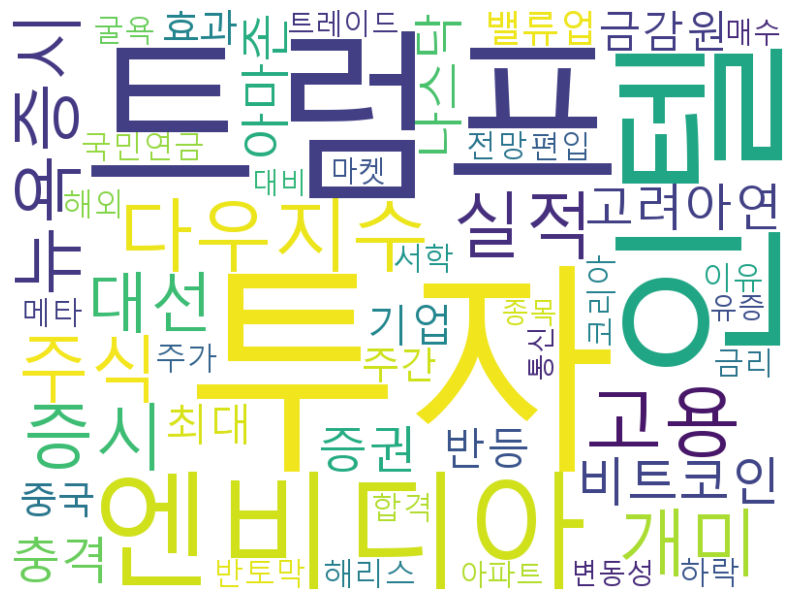

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

font_path = 'C:\Windows\Fonts\malgun.ttf'  # 한글 폰트 경로 (한글 깨짐 방지)
wc = WordCloud(font_path=font_path, background_color='white', width=800, height=600)

# 앞서 계산한 단어 빈도 사용하여 워드클라우드 생성
cloud = wc.generate_from_frequencies(top50)  # 또는 wc.generate_from_frequencies(counter) 전체 단어 사용

# 워드클라우드 이미지 시각화
plt.figure(figsize=(10, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')  # 축 제거
plt.show()


In [11]:
# 엔비디아 포함하는 뉴스 제목만 필터링
df = pd.read_csv(data_file)
df[df['title'].str.contains('엔비디아')]['title']

6        인텔 밀려난 자리에 엔비디아 입성...미 다우지수
9        인텔의 '굴욕'…엔비디아에 밀려 다우지수서 빠졌다
14       엔비디아, 다우지수 편입…인텔은 25년만에 밀려나
18         인텔의 굴욕...엔비디아에 밀려 다우지수 퇴출
34    몰락한 인텔, 다우지수서 빠졌다…엔비디아가 대체(종합)
44         [속보]엔비디아, 인텔 물리치고 다우지수 편입
Name: title, dtype: object

In [12]:
# 비트코인을 포함하는 뉴스 제목만 필터링
df = pd.read_csv(data_file)
df[df['title'].str.contains('비트코인')]['title']

8           미 대선 사흘 앞으로… 비트코인 '2억원 꿈' 실현되나
31    트럼프 당선되면 얼마나 오를까…타오르는 비트코인 [투자의 재발견]
59    "비트코인이 미래다"…287% 급등한 이 기업, 비트코인 더 산다
Name: title, dtype: object